In [1]:
import pandas as pd
import numpy as np

## Extract table

In [ ]:
data1 = pd.read_excel("data/extract2.xlsx")
data1.drop(index=0, inplace=True)
data1.drop(columns=['PLY_NO', 'PYG_GST', 'APR_FLG', 'BSN_USE', 'BLD_CLM_CNT'], inplace=True)   # dropping cols with same values throughout
data1.reset_index(drop=True, inplace=True)
data1

,PLY_PRD,CST_OCP,TIR_PRM_AM,UCP_DY,UCP_RSN,OWS_DTL,SUM_INU,PRM_AM,PRM_WTH_IPT,RSK_PRM_INC_CRD_SCR,...,TIR_RSK_PRM,ITM_LMT_VL,MAN_PRT_PRM,ACD_PRM,OBL_PRM,PRV_ISN_BLD,PRV_ISN_CNE,PPT_ELG,RSK_PRM_OVR_TAX_SCG,CTS_CLM_CNT
0,DC1,RETI,0,30,Pendingsale(deceased),OR,NaN,NaN,NaN,NaN,...,0,550000,NaN,NaN,NaN,9,9,1,15.68,NaN
1,DC1,OTHR,195.2,30,NaN,OR,500000,174.29,195.2,162.41,...,159.51,99999999,NaN,NaN,NaN,5,5,1,34.8,0
2,DC1,OTHR,NaN,30,NaN,OR,0,39.6,NaN,NaN,...,NaN,99999999,1.789269,0.515735,0,7,7,1,77.99,0
3,DC1,OTHR,0,30,Pendingsale(deceased),UR,0,0,0,0,...,0,100000,NaN,NaN,NaN,0,2,1,27.13,0
4,DC1,RETI,0,30,NaN,OR,0,0,0,NaN,...,0,75000,0.688533,0.111698,0.068097,99,9,1,24.39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,DC1,RETI,0,30,NaN,OR,0,0,0,NaN,...,0,1000000,4.24824,0.3502,0.33187,99,4,1,31.32,0
72,DC1,OTHR,0,30,Pendingsale(deceased),FR,NaN,NaN,NaN,NaN,...,38.92,100000000,NaN,NaN,NaN,0,0,1,57.67,0
73,DC1,RETI,0,30,NaN,OR,NaN,NaN,NaN,NaN,...,0,100000,NaN,NaN,NaN,99,99,NaN,41.34,0
74,DC1,RETI,27.59,30,NaN,OR,2000,24.63,27.59,NaN,...,11.7,5000,9.31995,0.39542,0,99,0,NaN,27.06,0


In [3]:
print("Column, Missing Values, Unique Values")
for col in data1.columns:
    print(f"{col}, {data1[col].isna().sum()}, {data1[col].nunique()}")

Column, Missing Values, Unique Values
PLY_PRD, 0, 2
CST_OCP, 20, 3
TIR_PRM_AM, 8, 24
UCP_DY, 18, 2
UCP_RSN, 42, 1
OWS_DTL, 18, 4
SUM_INU, 37, 10
PRM_AM, 37, 17
PRM_WTH_IPT, 40, 15
RSK_PRM_INC_CRD_SCR, 64, 8
RSK_PRM_NO_CRD_SCR, 64, 8
CVR_IND, 10, 2
CVR_TYP_LMT, 60, 6
CVR_SEL, 45, 2
TIR_LMT_VL, 25, 11
TIR_RSK_PRM, 3, 30
ITM_LMT_VL, 3, 20
MAN_PRT_PRM, 42, 31
ACD_PRM, 42, 26
OBL_PRM, 42, 22
PRV_ISN_BLD, 6, 11
PRV_ISN_CNE, 6, 11
PPT_ELG, 25, 1
RSK_PRM_OVR_TAX_SCG, 0, 76
CTS_CLM_CNT, 35, 2


In [4]:
categorical_cols = ["CST_OCP", "UCP_DY", "OWS_DTL", "CVR_IND", "CVR_SEL", "CTS_CLM_CNT"]

# Replace string indicators of missingness with NaN
data1.replace(["", "NA", "None"], np.nan, inplace=True)

for col in categorical_cols:
    if col in data1.columns:
        choices = data1[col].dropna().unique()
        data1[col] = data1[col].apply(lambda x: np.random.choice(choices) if pd.isna(x) else x)

# standard_fill_cols
data1["UCP_RSN"] = data1["UCP_RSN"].fillna("Unknown")
data1["PPT_ELG"] = data1["PPT_ELG"].fillna(0)

C:\Users\niksh\AppData\Local\Temp\ipykernel_17260\3220750870.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data1.replace(["", "NA", "None"], np.nan, inplace=True)


In [5]:
categorical_cols.append("UCP_RSN")
categorical_cols.append("PPT_ELG")
categorical_cols.append("PLY_PRD")

rem_cols = data1.columns.difference(categorical_cols).tolist()

from scipy.stats import norm

for col in rem_cols:
    if col in data1.columns:
        non_null_values = data1[col].dropna().values
        if len(non_null_values) == 0:
            continue

        # Fit a normal distribution
        mu, sigma = norm.fit(non_null_values)

        n_missing = data1[col].isna().sum()
        # Generate samples
        sampled_values = np.random.normal(mu, sigma, n_missing)

        # Ensure no negatives — resample those that are < 0
        while np.any(sampled_values < 0):
            neg_idx = sampled_values < 0
            sampled_values[neg_idx] = np.random.normal(mu, sigma, np.sum(neg_idx))

        data1.loc[data1[col].isna(), col] = sampled_values

In [ ]:
data1.to_csv("extract2_cleaned.csv", index=False)

## Fraud Table

In [ ]:
data2 = pd.read_excel("data/fraud.xlsx")
data2 = data2.dropna(subset=['CLAIM_TYPE_DESCRIPTION']).reset_index(drop=True)
data2

,REGISTERED_DATE,LOSS_DATE,CLAIM_TYPE_DESCRIPTION,INVEST_DATE,Closed Date,SAVED_VALUE_ESTIMATE,ACTION_STATUS_DESCRIPTION,PRODUCT_CODE,REASON,Rule Outcome Code,ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME
0,2023-04-17,2023-04-17,Escape of Water,2023-04-20,2023-05-12,3000.0,Suspect,HAS,Fraud Suspected - Exaggerated,S003,2023-04-19 12:00:10.447
1,2023-04-17,2023-04-16,Theft,2023-04-17,2023-04-17,0.0,Clear after Investigation,HAA,Null,S003,2023-04-17 15:33:45.303
2,2023-04-17,2023-02-18,Theft,2023-04-20,2023-04-25,45190.0,Clear after Investigation,DC1,Null,S002,2023-04-20 09:31:44.437
3,2023-04-17,2023-04-17,Accidental damage Option,2023-04-18,2023-05-25,343.0,Suspect,DC1,Fraud Suspected - Claim Paid,S001,2023-04-17 16:15:32.263
4,2023-04-17,2023-04-15,Accidental damage Option,2023-04-25,2023-10-03,3000.0,Suspect,DC1,Fraud Suspected - Exaggerated,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...
9355,2025-07-28,2025-07-20,Escape of Water,2025-08-02,2025-08-05,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 13:14:30.467
9356,2025-07-28,2025-07-28,Fire,2025-07-31,2025-07-31,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 15:59:23.347
9357,2025-08-01,2025-08-01,Fire,2025-08-07,2025-08-07,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:22:51.573
9358,2025-08-01,2025-07-31,Accidental loss (EXC),2025-08-08,2025-08-13,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:50:01.883


In [33]:
print("Column, Missing Values, Unique Values")
for col in data2.columns:
    print(f"{col}, {data2[col].isna().sum()}, {data2[col].nunique()}")

Column, Missing Values, Unique Values
REGISTERED_DATE, 0, 798
LOSS_DATE, 0, 925
CLAIM_TYPE_DESCRIPTION, 0, 19
INVEST_DATE, 0, 675
Closed Date, 0, 655
SAVED_VALUE_ESTIMATE, 0, 1193
ACTION_STATUS_DESCRIPTION, 0, 3
PRODUCT_CODE, 0, 8
REASON, 0, 24
Rule Outcome Code, 89, 3
ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME, 89, 9271


In [34]:
col = "Rule Outcome Code"
choices = data2[col].dropna().unique()
data2[col] = data2[col].apply(lambda x: np.random.choice(choices) if pd.isna(x) else x)

# Fill NA in ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME with a random date between REGISTERED_DATE and REGISTERED_DATE + 4 days, using normal distribution
mask = data2['ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME'].isna()
register_dates = data2.loc[mask, 'REGISTERED_DATE']

# Generate random offsets (in days) from a normal distribution centered at 2, std=1, clipped to [0, 4]
offsets = np.clip(np.random.normal(loc=2, scale=1, size=mask.sum()), 0, 4)
random_dates = register_dates + pd.to_timedelta(offsets, unit='D')

data2.loc[mask, 'ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME'] = random_dates
data2

,REGISTERED_DATE,LOSS_DATE,CLAIM_TYPE_DESCRIPTION,INVEST_DATE,Closed Date,SAVED_VALUE_ESTIMATE,ACTION_STATUS_DESCRIPTION,PRODUCT_CODE,REASON,Rule Outcome Code,ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME
0,2023-04-17,2023-04-17,Escape of Water,2023-04-20,2023-05-12,3000.0,Suspect,HAS,Fraud Suspected - Exaggerated,S003,2023-04-19 12:00:10.447000000
1,2023-04-17,2023-04-16,Theft,2023-04-17,2023-04-17,0.0,Clear after Investigation,HAA,Null,S003,2023-04-17 15:33:45.303000000
2,2023-04-17,2023-02-18,Theft,2023-04-20,2023-04-25,45190.0,Clear after Investigation,DC1,Null,S002,2023-04-20 09:31:44.437000000
3,2023-04-17,2023-04-17,Accidental damage Option,2023-04-18,2023-05-25,343.0,Suspect,DC1,Fraud Suspected - Claim Paid,S001,2023-04-17 16:15:32.263000000
4,2023-04-17,2023-04-15,Accidental damage Option,2023-04-25,2023-10-03,3000.0,Suspect,DC1,Fraud Suspected - Exaggerated,S003,2023-04-19 14:36:43.570258989
...,...,...,...,...,...,...,...,...,...,...,...
9355,2025-07-28,2025-07-20,Escape of Water,2025-08-02,2025-08-05,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 13:14:30.467000000
9356,2025-07-28,2025-07-28,Fire,2025-07-31,2025-07-31,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 15:59:23.347000000
9357,2025-08-01,2025-08-01,Fire,2025-08-07,2025-08-07,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:22:51.573000000
9358,2025-08-01,2025-07-31,Accidental loss (EXC),2025-08-08,2025-08-13,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:50:01.883000000


In [ ]:
data2.to_csv("fraud_cleaned.csv", index=False)

## Scaling

In [ ]:
from scipy.stats import gaussian_kde

def scale_dataframe(data, target_rows, categorical_cols, numeric_cols, random_state=None):
    """
    Scale up a mixed-type DataFrame to target_rows by synthetic resampling 
    while preserving per-column data distributions.
    """
    np.random.seed(random_state)
    new_data = pd.DataFrame()

    # --- Handle categorical columns ---
    for col in categorical_cols:
        if col not in data.columns:
            continue
        col_data = data[col]
        # Compute probability of each category
        probs = col_data.value_counts(normalize=True)
        # Sample categories according to observed frequency
        sampled = np.random.choice(probs.index, size=target_rows, p=probs.values)
        new_data[col] = sampled

    # --- Handle numeric columns ---
    for col in numeric_cols:
        if col not in data.columns:
            continue
        col_data = data[col].values
        # Fit Kernel Density Estimation (KDE)
        kde = gaussian_kde(col_data)
        # Generate synthetic samples
        sampled = kde.resample(target_rows).reshape(-1)
        # Clip to observed range (optional, ensures realism)
        sampled = np.clip(sampled, col_data.min(), col_data.max())
        new_data[col] = sampled

    # Preserve column order as in the original DataFrame
    new_data = new_data[data.columns]

    return new_data.reset_index(drop=True)

# Generate scaled data
scaled_data1 = scale_dataframe(data1, target_rows=15000,
                              categorical_cols=categorical_cols,
                              numeric_cols=rem_cols,
                              random_state=42)

scaled_data1.to_csv("scaled_extract2.csv", index=False)

In [ ]:
def scale_dataframe2(
    data,
    target_rows,
    date_cols,
    categorical_cols,
    numeric_cols,
    random_state=None
):
    """
    Rule-based synthetic scaling of a mixed-type dataframe with:
    - Date columns (sampled within range)
    - Categorical columns (sampled by frequency)
    - Numeric columns (KDE resampling)
    """

    if random_state is not None:
        np.random.seed(random_state)

    new_data = pd.DataFrame()

    # --- 1. DATE COLUMNS -----------------------------------------------------
    for col in date_cols:
        if col not in data.columns:
            continue
        
        # Convert to datetime (if not already)
        col_data = pd.to_datetime(data[col])

        # Range of observed dates
        min_date = col_data.min()
        max_date = col_data.max()

        # Sample random dates within observed range
        total_days = (max_date - min_date).days
        rand_days = np.random.randint(0, total_days + 1, size=target_rows)
        sampled_dates = min_date + pd.to_timedelta(rand_days, unit="D")

        new_data[col] = sampled_dates.astype(str)

    # --- 2. CATEGORICAL COLUMNS --------------------------------------------
    for col in categorical_cols:
        if col not in data.columns:
            continue

        col_data = data[col]
        probs = col_data.value_counts(normalize=True)

        sampled = np.random.choice(
            probs.index,
            size=target_rows,
            p=probs.values
        )
        new_data[col] = sampled

    # --- 3. NUMERIC COLUMNS --------------------------------------------------
    for col in numeric_cols:
        if col not in data.columns:
            continue
        
        col_data = data[col].astype(float).values

        # KDE Fit
        kde = gaussian_kde(col_data)

        sampled_vals = kde.resample(target_rows).reshape(-1)

        # Clip to keep realism
        sampled_vals = np.clip(sampled_vals, col_data.min(), col_data.max())

        new_data[col] = sampled_vals

    # Match column ordering with original dataframe
    new_data = new_data[data.columns]

    return new_data.reset_index(drop=True)

date_cols = [
    "REGISTERED_DATE",
    "LOSS_DATE",
    "INVEST_DATE",
    "Closed Date",
    "ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME"
]

categorical_cols = [
    "CLAIM_TYPE_DESCRIPTION",
    "ACTION_STATUS_DESCRIPTION",
    "PRODUCT_CODE",
    "REASON",
    "Rule Outcome Code"
]

numeric_cols = ["SAVED_VALUE_ESTIMATE"]

scaled_data2 = scale_dataframe2(
    data=data2,
    target_rows=15000,
    date_cols=date_cols,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    random_state=42
)

scaled_data2.to_csv("fraud_scaled.csv", index=False)

In [ ]:
scaled_data1 = scaled_data1.reset_index(drop=True)
scaled_data2 = scaled_data2.reset_index(drop=True)

data3 = pd.concat([scaled_data1, scaled_data2], axis=1)
data3

In [ ]:
data3.to_csv("combined_scaled.csv", index=False)

## Feature expansion - new data generation

In [19]:
import numpy as np
import pandas as pd
import random
from scipy.special import expit

In [20]:
data = pd.read_csv("data/data_template.csv")
data

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,plumbing_elec_age,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims,premium_payment_behaviour,property_market_value,short_term_letting
0,Random no,Random 6 categorical values,"Categorical - (housewife, retired, other)","categorical - 1, 2, 3",Tier based values,"how many occupants in house, including owners ...",no of PGs,Y/N,"30, 60, 90",unoccupied reason,...,age of plumbing and electrical equipmements,0 or 1,0 or 1,0 or 1,1 to 5,urban/rural,no of claims in last 5 years,metric of the history of the customer's paymen...,"market value of the property, in logical accor...",is the property open for short term letting li...


In [21]:
def generate_uk_home_insurance_data(n_records=1000):
    """
    Generate realistic UK home insurance data based on demographics and market research.
    Returns: List of dictionaries with insurance policy data
    """
    
    data = []
    
    # Product categories based on UK market
    products = ['Buildings', 'Contents', 'Combined', 'Landlord', 'Premium Combined', 'Standard']
    
    # Occupation distribution (UK weighted)
    occupations = {
        'retired': 0.28,
        'housewife': 0.08,
        'professional': 0.22,
        'white_collar': 0.30,
        'skilled_worker': 0.08,
        'other': 0.04
    }
    
    # Property type distribution (UK 2024)
    property_types = {
        'Terraced': 0.26,
        'Semi': 0.24,
        'Flat': 0.24,
        'Detached': 0.19,
        'Bungalow': 0.07
    }
    
    # Urban/rural split (UK ~83% urban)
    urban_rural_dist = {'urban': 0.83, 'rural': 0.17}
    
    for i in range(n_records):
        # Basic policy info
        policy_no = 100000 + i
        policy_product = random.choice(products)
        
        # Occupation
        cust_occupation = random.choices(
            list(occupations.keys()),
            weights=list(occupations.values())
        )[0]
        
        # Tier (1=basic, 2=standard, 3=premium)
        tier = random.choices([1, 2, 3], weights=[0.35, 0.50, 0.15])[0]
        
        # Tier-based premium amounts
        tier_premium_base = {1: 180, 2: 320, 3: 580}
        tier_premium_amt = tier_premium_base[tier] * random.uniform(0.85, 1.15)
        
        # Property type
        property_type = random.choices(
            list(property_types.keys()),
            weights=list(property_types.values())
        )[0]
        
        # Occupants (1-6, weighted toward 2-4)
        occupants_count = random.choices([1, 2, 3, 4, 5, 6], weights=[0.15, 0.30, 0.25, 0.20, 0.07, 0.03])[0]
        
        # Paying guests (0-2, mostly 0)
        paying_guest_no = random.choices([0, 1, 2], weights=[0.92, 0.06, 0.02])[0]
        
        # Business use (5% have it)
        business_use = 'Y' if random.random() < 0.05 else 'N'
        
        # Unoccupied days (90% have 0, rest have 30/60/90)
        unoccupied_days = random.choices([0, 30, 60, 90], weights=[0.90, 0.05, 0.03, 0.02])[0]
        unoccupied_reason = random.choice(['', 'holiday_home', 'renovation', 'relocation']) if unoccupied_days > 0 else ''
        
        # Owner details
        owner_details = random.choices(
            ['owner', 'user', 'legal_lease', 'financier'],
            weights=[0.75, 0.15, 0.08, 0.02]
        )[0]
        
        # Sum insured (rebuild cost, varies by property type)
        base_sum_insured = {
            'Flat': 200000,
            'Terraced': 300000,
            'Semi': 350000,
            'Bungalow': 320000,
            'Detached': 500000
        }
        sum_insured = int(base_sum_insured[property_type] * random.uniform(0.7, 1.8) / 50000) * 50000
        
        # Premium calculations (realistic UK ranges)
        base_premium = tier_premium_amt
        
        # Adjust for property type
        property_multipliers = {'Flat': 1.15, 'Terraced': 0.95, 'Semi': 1.0, 'Bungalow': 0.98, 'Detached': 1.25}
        base_premium *= property_multipliers[property_type]
        
        # Risk premiums
        risk_premium_with_credit_score = base_premium * random.uniform(0.92, 0.98)
        risk_premium_without_credit_score = risk_premium_with_credit_score * random.uniform(1.05, 1.15)
        
        # Premium with tax (12% insurance premium tax in UK)
        premium_with_tax = risk_premium_with_credit_score * 1.12
        
        # Coverage selected (70% yes)
        coverage_selected = 1 if random.random() < 0.70 else 0
        
        # Additional coverage amount
        additional_coverage_amount = random.choice([0, 5000, 10000, 15000, 25000]) if coverage_selected else 0
        
        # Tier limits and values
        tier_limit_value = tier * 50000
        tier_risk_premium = tier_premium_amt * 0.85
        item_limit_value = random.choice([5000, 10000, 15000, 20000])
        
        # Component premiums
        main_part_premium = base_premium * 0.65
        accidental_damage_premium = base_premium * 0.20 if random.random() < 0.60 else 0
        outbuildings_premium = base_premium * 0.10 if property_type in ['Detached', 'Semi', 'Bungalow'] and random.random() < 0.35 else 0
        
        # Auto renewal flag
        APR_FLAG = 1 if random.random() < 0.55 else 0
        
        # Previous insurance (70% had buildings, 65% had contents)
        previous_insurance_buildings = 1 if random.random() < 0.70 else 0
        previous_insurance_cne = 1 if random.random() < 0.65 else 0
        
        # Property eligibility (contents covered with house)
        property_eligibility = 1 if policy_product in ['Combined', 'Premium Combined'] else 0
        
        # Risk override tax
        risk_premium_override_tax = risk_premium_with_credit_score * 0.08 * random.uniform(0.8, 1.2)
        
        # Claims history (most have 0, few have 1-3)
        contents_claim_counts = random.choices([0, 1, 2, 3], weights=[0.82, 0.12, 0.04, 0.02])[0]
        building_claim_count = random.choices([0, 1, 2, 3], weights=[0.85, 0.10, 0.03, 0.02])[0]
        
        # Risk scores (1-5, weighted toward middle)
        flood_risk = random.choices([1, 2, 3, 4, 5], weights=[0.40, 0.30, 0.20, 0.07, 0.03])[0]
        storm_risk = random.choices([1, 2, 3, 4, 5], weights=[0.35, 0.30, 0.22, 0.10, 0.03])[0]
        other_natural_calamities_risk = random.choices([1, 2, 3, 4, 5], weights=[0.45, 0.28, 0.18, 0.07, 0.02])[0]
        
        # Property age (years) - UK has old housing stock
        property_age_bands = {
            'pre_1900': (125, 200),
            '1900_1944': (80, 124),
            '1945_1980': (44, 79),
            '1981_2000': (24, 43),
            '2001_2020': (4, 23),
            'post_2020': (0, 3)
        }
        age_band = random.choices(
            list(property_age_bands.keys()),
            weights=[0.20, 0.25, 0.28, 0.15, 0.10, 0.02]
        )[0]
        property_age = random.randint(*property_age_bands[age_band])
        
        # Construction and roof materials
        construction_material = random.choices(
            ['bricks', 'cement', 'wood', 'stone'],
            weights=[0.70, 0.20, 0.05, 0.05]
        )[0]
        roof_material = random.choices(
            ['tiles', 'slate', 'cement', 'wood'],
            weights=[0.55, 0.25, 0.15, 0.05]
        )[0]
        
        # Number of rooms (1-6+, weighted by property type)
        if property_type == 'Flat':
            no_of_rooms = random.choices([1, 2, 3, 4], weights=[0.25, 0.45, 0.25, 0.05])[0]
        elif property_type == 'Terraced':
            no_of_rooms = random.choices([2, 3, 4, 5], weights=[0.15, 0.55, 0.25, 0.05])[0]
        elif property_type == 'Semi':
            no_of_rooms = random.choices([2, 3, 4, 5], weights=[0.10, 0.45, 0.35, 0.10])[0]
        elif property_type == 'Bungalow':
            no_of_rooms = random.choices([2, 3, 4], weights=[0.35, 0.50, 0.15])[0]
        else:  # Detached
            no_of_rooms = random.choices([3, 4, 5, 6], weights=[0.20, 0.40, 0.30, 0.10])[0]
        
        # Plumbing/electrical age (0-50 years)
        plumbing_elec_age = min(property_age, random.randint(5, 40))
        
        # Smart home, fire safety, security (increasing adoption)
        smart_home = 1 if random.random() < 0.28 else 0
        fire_safety_systems = 1 if random.random() < 0.45 else 0
        security_systems = 1 if random.random() < 0.52 else 0
        
        # Crime rate (1-5, area dependent)
        urban_rural = random.choices(
            list(urban_rural_dist.keys()),
            weights=list(urban_rural_dist.values())
        )[0]
        if urban_rural == 'urban':
            crime_rate = random.choices([1, 2, 3, 4, 5], weights=[0.15, 0.30, 0.35, 0.15, 0.05])[0]
        else:
            crime_rate = random.choices([1, 2, 3, 4, 5], weights=[0.40, 0.35, 0.18, 0.05, 0.02])[0]
        
        # Total claims in last 5 years
        no_of_claims_5yr = contents_claim_counts + building_claim_count
        
        # Premium payment behaviour (score 0-100, higher is better)
        premium_payment_behaviour = int(random.triangular(60, 100, 85))
        
        # Property market value (higher than sum insured typically)
        property_market_value = int(sum_insured * random.uniform(1.1, 1.8) / 10000) * 10000
        
        # Short term letting (Airbnb) - about 2% of properties
        short_term_letting = 1 if random.random() < 0.02 else 0
        
        # Create record
        record = {
            'policy_no': policy_no,
            'policy_product': policy_product,
            'cust_occupation': cust_occupation,
            'tier': tier,
            'tier_premium_amt': round(tier_premium_amt, 2),
            'occupants_count': occupants_count,
            'paying_guest_no': paying_guest_no,
            'business_use': business_use,
            'unoccupied_days': unoccupied_days,
            'unoccupied_reason': unoccupied_reason,
            'owner_details': owner_details,
            'sum_insured': sum_insured,
            'premium_with_tax': round(premium_with_tax, 2),
            'risk_premium_with_credit_score': round(risk_premium_with_credit_score, 2),
            'risk_premium_without_credit_score': round(risk_premium_without_credit_score, 2),
            'coverage_selected': coverage_selected,
            'additional_coverage_amount': additional_coverage_amount,
            'tier_limit_value': tier_limit_value,
            'tier_risk_premium': round(tier_risk_premium, 2),
            'item_limit_value': item_limit_value,
            'main_part_premium': round(main_part_premium, 2),
            'accidental_damage_premium': round(accidental_damage_premium, 2),
            'outbuildings_premium': round(outbuildings_premium, 2),
            'APR_FLAG': APR_FLAG,
            'previous_insurance_buildings': previous_insurance_buildings,
            'previous_insurance_cne': previous_insurance_cne,
            'property_eligibility': property_eligibility,
            'risk_premium_override_tax': round(risk_premium_override_tax, 2),
            'contents_claim_counts': contents_claim_counts,
            'building_claim_count': building_claim_count,
            'flood_risk': flood_risk,
            'storm_risk': storm_risk,
            'other_natural_calamities_risk': other_natural_calamities_risk,
            'property_age': property_age,
            'property_type': property_type,
            'construction_material': construction_material,
            'roof_material': roof_material,
            'no_of_rooms': no_of_rooms,
            'plumbing_elec_age': plumbing_elec_age,
            'smart_home': smart_home,
            'fire_safety_systems': fire_safety_systems,
            'security_systems': security_systems,
            'crime_rate': crime_rate,
            'urban_rural': urban_rural,
            'no_of_claims_5yr': no_of_claims_5yr,
            'premium_payment_behaviour': premium_payment_behaviour,
            'property_market_value': property_market_value,
            'short_term_letting': short_term_letting
        }
        
        data.append(record)
    return data

data = generate_uk_home_insurance_data(500000)
df = pd.DataFrame(data)

In [27]:
def generate_harder_labels(
    df,
    seed: int = 42,
    noise_rate: float = 0.05,
    hard_high_frac: float = 0.20,
    add_xor: bool = True
):
    """
    Generate fraud probability on top of input dataframe `df`.
    Modified to avoid concentrated mass at probability==1.0.
    """
    rng = np.random.RandomState(seed)
    df = df.copy()

    def _col(name, default=0.0):
        return df[name].values if name in df.columns else np.full(len(df), default, dtype=float)

    # basic numeric features (fall back to defaults)
    sum_ins = _col('sum_insured', 0.0).astype(float)
    claims_5yr = _col('no_of_claims_5yr', 0.0).astype(float)
    premium_beh = _col('premium_payment_behaviour', 50.0).astype(float)
    occupants = _col('occupants_count', 1.0).astype(float)
    unoccupied = _col('unoccupied_days', 0.0).astype(float)
    property_age = _col('property_age', 25.0).astype(float)
    tier = _col('tier', 1.0).astype(float)
    paying_guest_no = _col('paying_guest_no', 0.0).astype(float)
    short_term_letting = _col('short_term_letting', 0.0).astype(float)
    smart_home = _col('smart_home', 0.0).astype(float)

    n = len(df)

    def norm(x):
        x = np.asarray(x, dtype=float)
        std = x.std() if x.std() > 0 else 1.0
        return (x - x.mean()) / std

    # base linear-ish index (kept small so it doesn't dominate)
    base = 0.35 * norm(claims_5yr) \
         - 0.20 * norm(premium_beh) \
         + 0.12 * norm(occupants) \
         + 0.08 * norm(unoccupied) \
         - 0.04 * norm(property_age) \
         + 0.06 * norm(tier)

    # Non-linear monotonic transforms (soften scales)
    mono1 = np.tanh(0.7 * norm(claims_5yr)) * 0.7
    mono2 = np.sign(norm(sum_ins)) * np.log1p(np.abs(norm(sum_ins))) * 0.4
    mono3 = np.tanh(0.5 * norm(occupants)) * 0.4

    # Interaction features
    interact1 = (norm(claims_5yr) * norm(premium_beh)) * 0.6
    interact2 = (norm(unoccupied) * (short_term_letting > 0).astype(float)) * 0.7

    # Rule-based abrupt regions (but smaller amplitude)
    rule1 = ((sum_ins > np.percentile(sum_ins, 85)) &
             (paying_guest_no >= 1) &
             (property_age > np.percentile(property_age, 60))).astype(float)

    rule2 = ((claims_5yr >= 2) & (premium_beh < 40)).astype(float)

    xor_rule = np.zeros(n)
    if add_xor:
        xor_rule = ((short_term_letting.astype(int) == 1) ^ (smart_home.astype(int) == 1)).astype(float)

    # Localized rectangle rule (reduce radius so it's not huge)
    axis_a = norm(_col('risk_premium_with_credit_score', 0.0))
    axis_b = norm(_col('risk_premium_without_credit_score', 0.0))
    center_a = rng.normal(0, 0.6, size=2)
    rect_mask = ((axis_a - center_a[0])**2 + (axis_b - center_a[1])**2) < 0.4
    rect_mask = rect_mask.astype(float)

    # Segment offsets (kept modest)
    if 'property_type' in df.columns:
        cats = pd.Categorical(df['property_type'])
        mapping = {k: (i % 3) * 0.35 for i, k in enumerate(cats.categories)}
        segment_offset = cats.codes.astype(float)
        for i, cat in enumerate(cats.categories):
            segment_offset[cats.codes == i] = mapping[cat]
    else:
        segment_offset = (rng.randint(0, 3, size=n) - 1) * 0.25

    # Combine components — use conservative weights and avoid hard additive jumps
    fraud_score = 0.30 * base \
                + 0.18 * mono1 \
                + 0.10 * mono2 \
                + 0.08 * mono3 \
                + 0.12 * interact1 \
                + 0.14 * interact2 \
                + 1.0 * rule1 \
                + 0.9 * rule2 \
                + 0.6 * xor_rule \
                + 0.6 * rect_mask \
                + 0.35 * segment_offset

    # small gaussian noise to avoid perfect determinism
    fraud_score = fraud_score + rng.normal(scale=0.20, size=n)

    # Smooth amplification with tanh saturation instead of hard additions
    fraud_score = fraud_score + 0.9 * np.tanh(np.clip(fraud_score - 1.2, -2.0, 5.0))

    # Make a fraction of the top-sum_insured rows "hard": keep scale small and clip
    if hard_high_frac > 0:
        k = max(1, int(np.floor(n * hard_high_frac)))
        high_idx = np.argsort(sum_ins)[-k:]
        hard_noise = rng.normal(scale=0.6, size=len(high_idx))
        hard_part = (0.25 * fraud_score[high_idx]) + (0.9 * xor_rule[high_idx]) + hard_noise
        # clip these to a reasonable range so logits don't explode
        fraud_score[high_idx] = np.clip(hard_part, -3.0, 3.0)

    # Per-segment temperature: clamp to a narrow band to avoid extreme sharpening
    temp = 1.0 + 0.35 * (segment_offset - segment_offset.mean())
    temp = np.clip(temp, 0.75, 1.25)

    def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
    fraud_prob = sigmoid(fraud_score * temp)

    # Small tier-based multiplicative adjustment but bounded
    if 'tier' in df.columns:
        tier_std = (tier - tier.mean()) / (tier.std() if tier.std() else 1.0)
        tier_adj = 1.0 + 0.08 * np.tanh(tier_std)   # bounded effect
        fraud_prob = fraud_prob * tier_adj

    # Optional label noise (flip a small fraction of final probabilities towards random)
    if noise_rate and noise_rate > 0:
        m = int(np.round(noise_rate * n))
        if m > 0:
            flip_idx = rng.choice(n, size=m, replace=False)
            # mix with uniform noise but don't set to exactly 1
            fraud_prob[flip_idx] = 0.6 * fraud_prob[flip_idx] + 0.4 * rng.rand(m)

    # add tiny jitter to break ties and avoid exact 0/1 after rounding
    fraud_prob = fraud_prob + rng.uniform(-1e-5, 1e-5, size=n)

    # Final clipping with a safe upper bound well below 1.0 to prevent rounding to 1.0000
    fraud_prob = np.clip(fraud_prob, 1e-6, 0.995)

    df_out = df.copy()
    df_out['fraud_probability'] = fraud_prob

    return df_out

df = generate_harder_labels(df, seed=123, noise_rate=0.05, hard_high_frac=0.20)

In [28]:
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting,fraud_probability
0,100000,Buildings,white_collar,1,178.30,3,0,N,0,,...,1,0,0,2,urban,2,91,190000,0,0.752082
1,100001,Contents,retired,2,339.22,3,0,N,0,,...,0,0,0,2,urban,0,66,350000,0,0.312372
2,100002,Combined,retired,3,500.55,6,0,N,0,,...,0,1,0,3,urban,0,70,400000,0,0.390236
3,100003,Landlord,professional,2,320.50,4,0,N,0,,...,1,1,0,4,urban,0,94,1130000,0,0.896196
4,100004,Premium Combined,professional,2,296.97,5,0,N,0,,...,0,0,1,2,urban,0,87,280000,0,0.205928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Combined,professional,2,301.70,4,1,N,0,,...,0,0,1,1,rural,1,85,880000,0,0.265820
499996,599996,Contents,retired,1,182.96,4,0,N,0,,...,0,0,1,3,rural,0,80,220000,0,0.346657
499997,599997,Premium Combined,retired,2,287.48,6,0,N,0,,...,0,0,0,3,urban,0,86,240000,0,0.381350
499998,599998,Combined,professional,3,597.03,4,0,N,0,,...,0,1,1,5,urban,0,70,490000,0,0.399406


In [24]:
df.columns

Index(['policy_no', 'policy_product', 'cust_occupation', 'tier',
       'tier_premium_amt', 'occupants_count', 'paying_guest_no',
       'business_use', 'unoccupied_days', 'unoccupied_reason', 'owner_details',
       'sum_insured', 'premium_with_tax', 'risk_premium_with_credit_score',
       'risk_premium_without_credit_score', 'coverage_selected',
       'additional_coverage_amount', 'tier_limit_value', 'tier_risk_premium',
       'item_limit_value', 'main_part_premium', 'accidental_damage_premium',
       'outbuildings_premium', 'APR_FLAG', 'previous_insurance_buildings',
       'previous_insurance_cne', 'property_eligibility',
       'risk_premium_override_tax', 'contents_claim_counts',
       'building_claim_count', 'flood_risk', 'storm_risk',
       'other_natural_calamities_risk', 'property_age', 'property_type',
       'construction_material', 'roof_material', 'no_of_rooms',
       'plumbing_elec_age', 'smart_home', 'fire_safety_systems',
       'security_systems', 'crime_rate',


=== Correlation with fraud_probability ===
fraud_probability                    1.000000
smart_home                           0.598902
no_of_claims_5yr                     0.298239
contents_claim_counts                0.219438
sum_insured                          0.205293
building_claim_count                 0.202395
main_part_premium                    0.197988
risk_premium_with_credit_score       0.197727
premium_with_tax                     0.197727
risk_premium_without_credit_score    0.197365
property_market_value                0.193938
risk_premium_override_tax            0.189966
tier_limit_value                     0.173849
tier                                 0.173849
tier_risk_premium                    0.160362
tier_premium_amt                     0.160362
accidental_damage_premium            0.087698
occupants_count                      0.086512
short_term_letting                   0.084502
no_of_rooms                          0.060600
Name: fraud_probability, dtype: floa

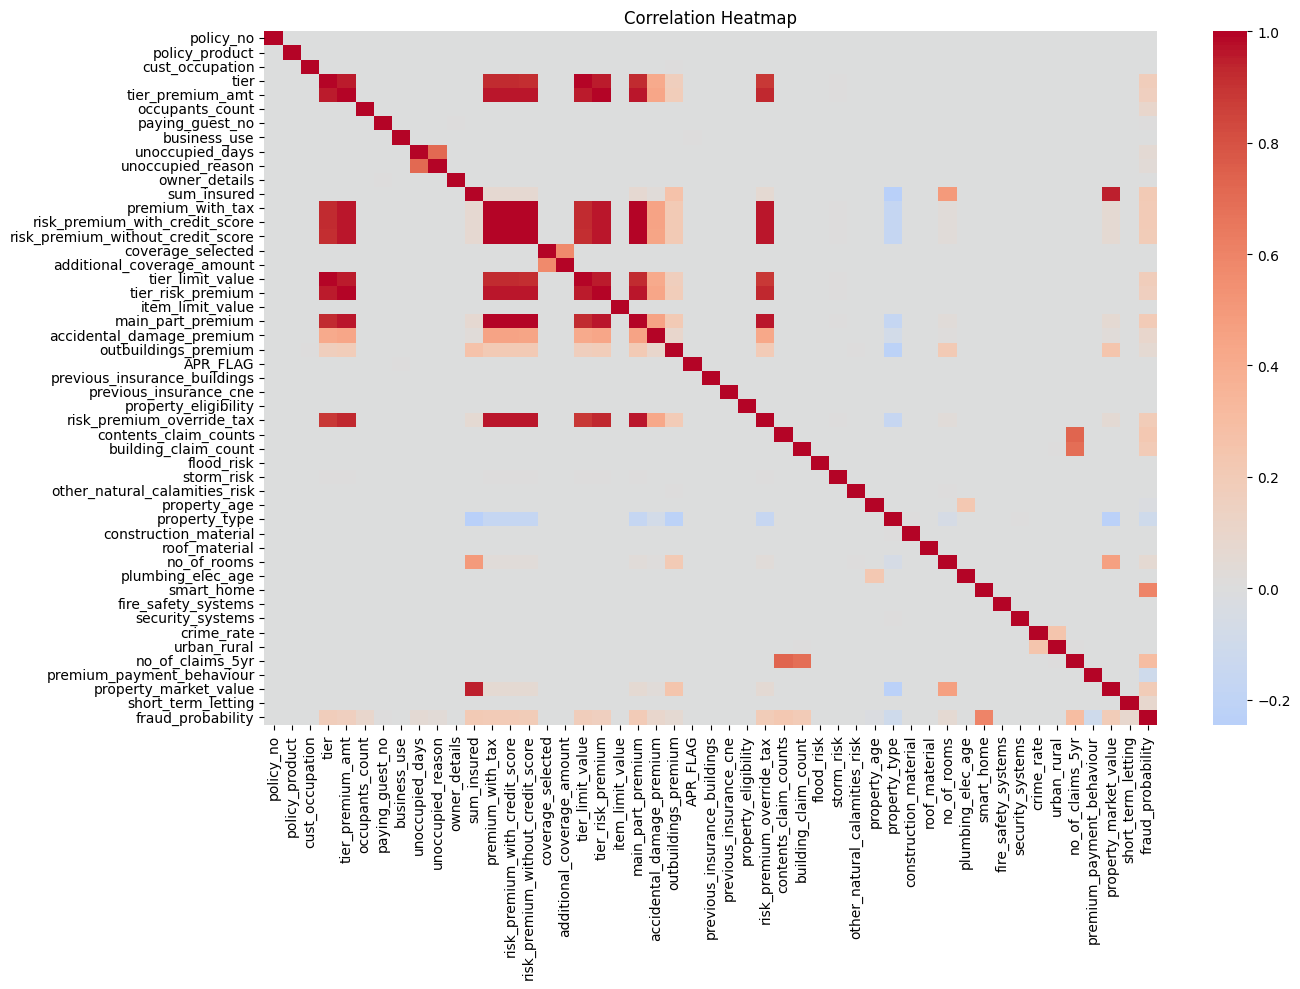


=== Missing Value % by Column ===
policy_no                            0.0
policy_product                       0.0
cust_occupation                      0.0
tier                                 0.0
tier_premium_amt                     0.0
occupants_count                      0.0
paying_guest_no                      0.0
business_use                         0.0
unoccupied_days                      0.0
unoccupied_reason                    0.0
owner_details                        0.0
sum_insured                          0.0
premium_with_tax                     0.0
risk_premium_with_credit_score       0.0
risk_premium_without_credit_score    0.0
coverage_selected                    0.0
additional_coverage_amount           0.0
tier_limit_value                     0.0
tier_risk_premium                    0.0
item_limit_value                     0.0
main_part_premium                    0.0
accidental_damage_premium            0.0
outbuildings_premium                 0.0
APR_FLAG              

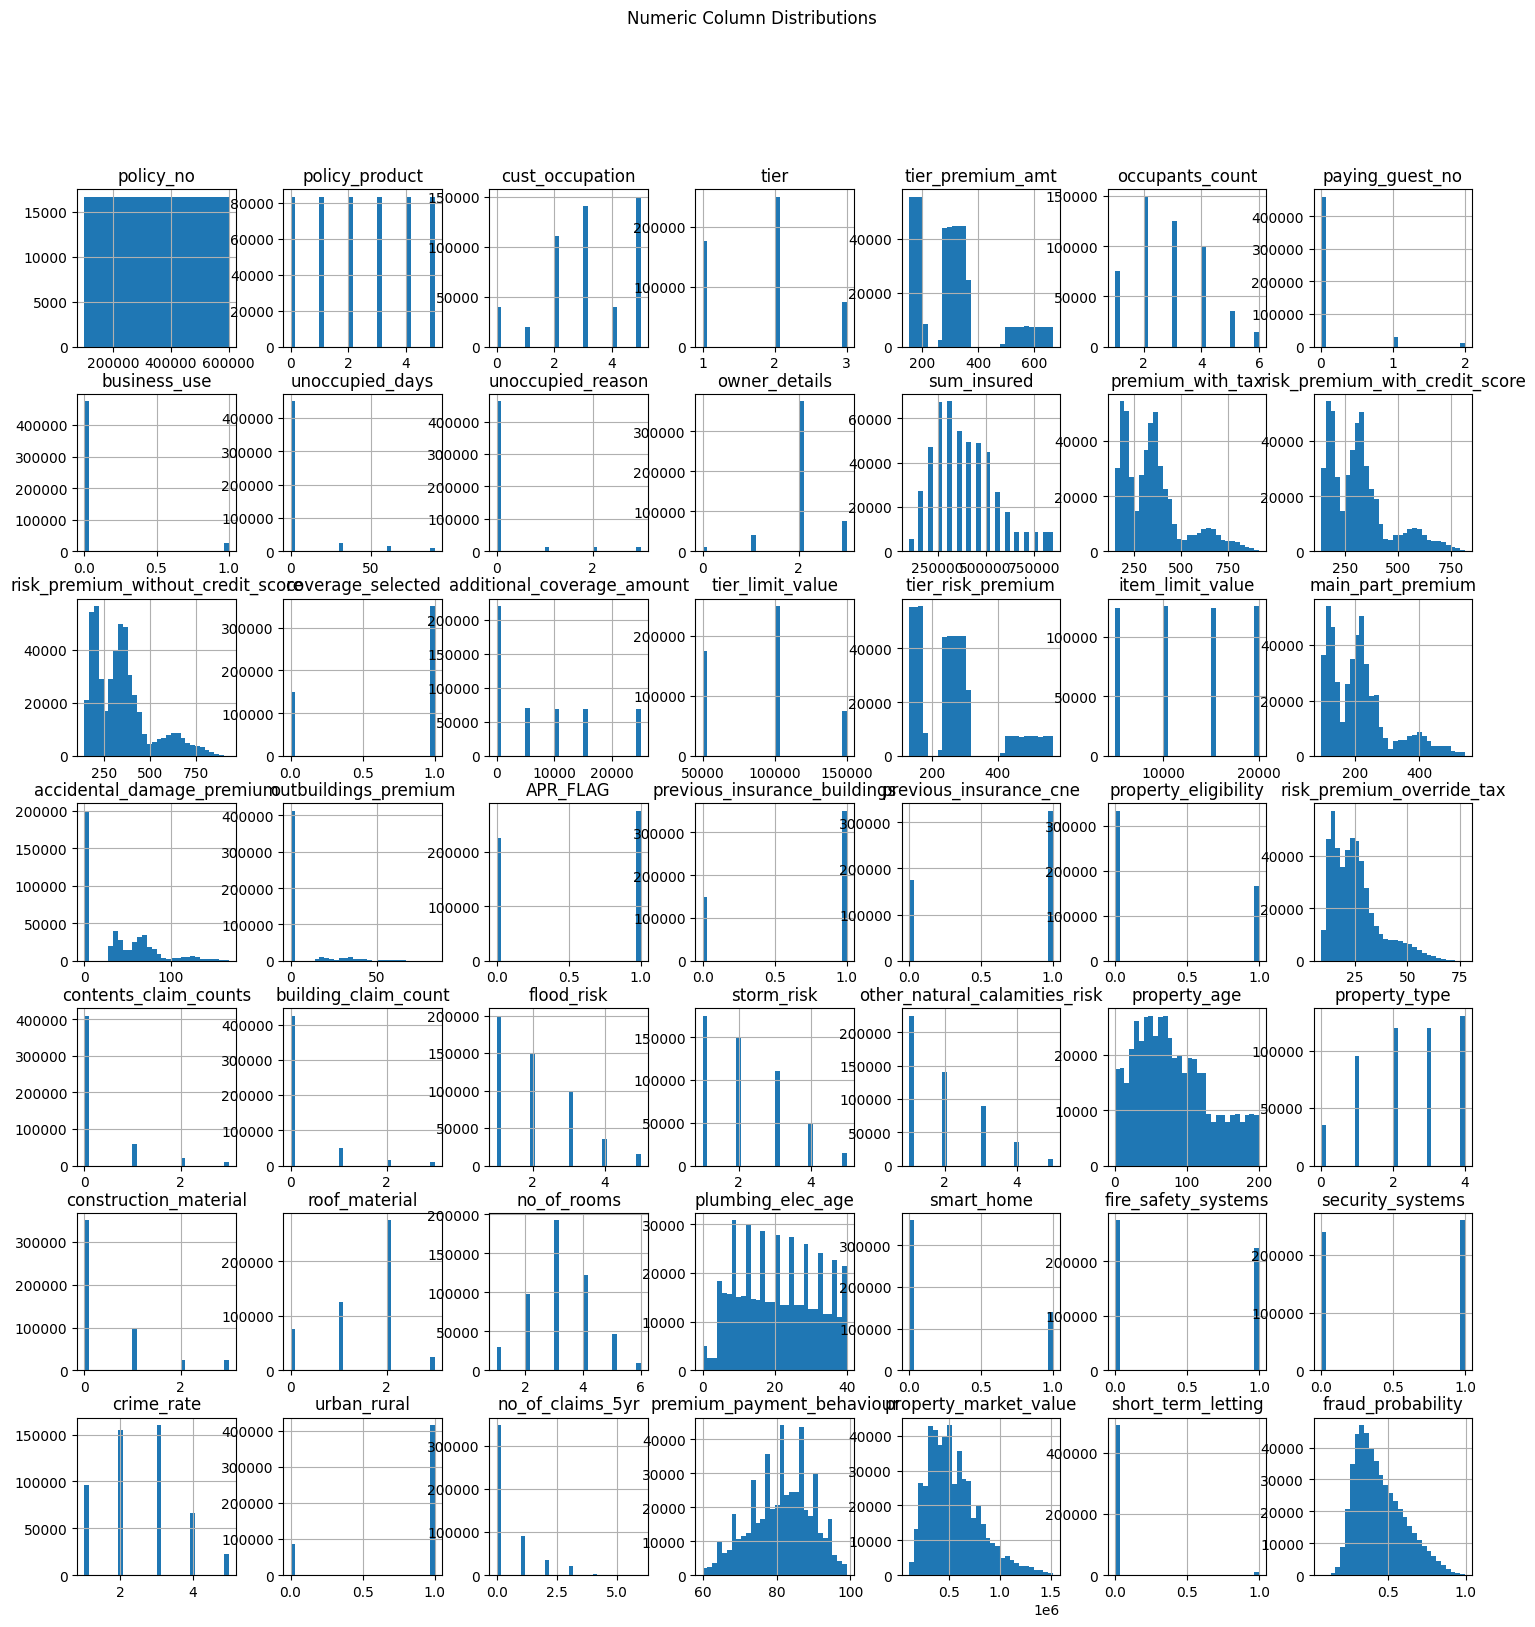


=== Category Counts (Top 20 Each) ===

--- policy_product ---
policy_product
Contents            83469
Premium Combined    83451
Combined            83370
Buildings           83364
Standard            83310
Landlord            83036
Name: count, dtype: int64

--- cust_occupation ---
cust_occupation
white_collar      149964
retired           140310
professional      110169
skilled_worker     39977
housewife          39659
other              19921
Name: count, dtype: int64

--- business_use ---
business_use
N    474916
Y     25084
Name: count, dtype: int64

--- unoccupied_reason ---
unoccupied_reason
                462291
renovation       12666
holiday_home     12534
relocation       12509
Name: count, dtype: int64

--- owner_details ---
owner_details
owner          374763
user            75178
legal_lease     40106
financier        9953
Name: count, dtype: int64

--- property_type ---
property_type
Terraced    130405
Flat        119955
Semi        119679
Detached     95002
Bungalow   

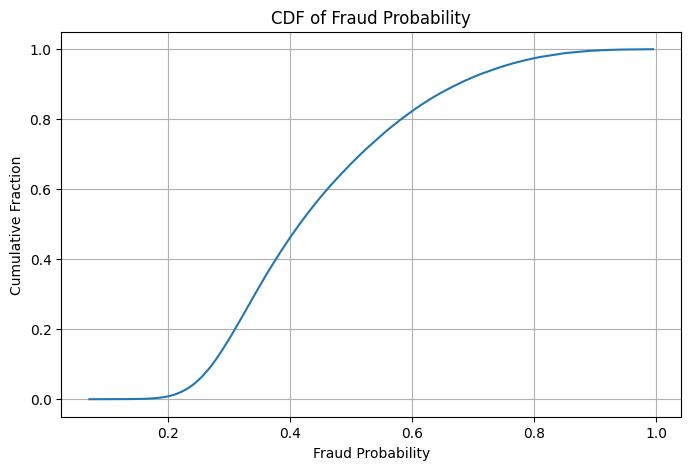


=== Recommended Thresholds ===
19% highest-risk threshold: 0.5818
9% highest-risk threshold: 0.6745
5% highest-risk threshold: 0.7469
2% highest-risk threshold: 0.8173


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. BASIC CLEANING
# ============================================
df_clean = df.copy()

# Convert categorical columns to numeric (label encoding)
from sklearn.preprocessing import LabelEncoder
cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

# ============================================
# 2. CORRELATION MATRIX (label + probability)
# ============================================
corr = df_clean.corr()

corr_with_prob = corr["fraud_probability"].sort_values(ascending=False)

print("\n=== Correlation with fraud_probability ===")
print(corr_with_prob.head(20))

# ===== Heatmap =====
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================================
# 3. INDUSTRY-STYLE EDA TOOLS
# ============================================

# Missing values
print("\n=== Missing Value % by Column ===")
print(df_clean.isnull().mean().sort_values(ascending=False) * 100)

# Distribution of key numeric fields
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

df_clean[numeric_cols].hist(figsize=(18, 18), bins=30)
plt.suptitle("Numeric Column Distributions")
plt.show()

# High-cardinality categorical levels
print("\n=== Category Counts (Top 20 Each) ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(20))

# ============================================
# 4. FRAUD PROBABILITY CDF (CUMULATIVE CURVE)
# ============================================

fraud_probs = df["fraud_probability"].sort_values().values
cdf = np.arange(1, len(fraud_probs)+1) / len(fraud_probs)

plt.figure(figsize=(8,5))
plt.plot(fraud_probs, cdf)
plt.xlabel("Fraud Probability")
plt.ylabel("Cumulative Fraction")
plt.title("CDF of Fraud Probability")
plt.grid(True)
plt.show()

# ============================================
# 5. NUMERIC THRESHOLD FINDER
# ============================================

# Example: flag top 2%, 5%, 10%, 20% highest risk cases
percentiles = [0.80, 0.90, 0.95, 0.98]

print("\n=== Recommended Thresholds ===")
for p in percentiles:
    threshold = np.quantile(fraud_probs, p)
    print(f"{int((1-p)*100)}% highest-risk threshold: {threshold:.4f}")

In [31]:
# Set UK-standard realistic fraud threshold
uk_threshold = 0.7469

df["fraud_label"] = (df["fraud_probability"] >= uk_threshold).astype(int)

print("UK-standard fraud threshold set at:", uk_threshold)
print("Fraud rate in dataset:", df["fraud_label"].mean())

df.to_csv("data_5L_new.csv", index=False)

UK-standard fraud threshold set at: 0.7469
Fraud rate in dataset: 0.049978
